<a href="https://colab.research.google.com/github/Dreamingdreamers/multimodal-emotion-recognition/blob/main/notebooks/01_eeg_deap_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
{
 "cells": [],
 "metadata": {},
 "nbformat": 4,
 "nbformat_minor": 2
}

{'cells': [], 'metadata': {}, 'nbformat': 4, 'nbformat_minor': 2}

In [53]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
import os
import pickle
import joblib
import numpy as np
import pandas as pd
from scipy.signal import welch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
        roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
        )
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns


In [55]:
RAW_EEG_PATH = '/content/drive/MyDrive/Multimodal_Emotion_Project/data/raw/deap/data_preprocessed_python'
PROCESSED_PATH = '/content/drive/MyDrive/Multimodal_Emotion_Project/data/processed'
MODEL_PATH = '/content/drive/MyDrive/Multimodal_Emotion_Project/models'

In [57]:
# Create output directories if they don't exist
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

In [58]:
# 3. Differential Entropy Extraction Helper
from scipy.stats import differential_entropy

def compute_hjorth_parameters(signal):
    """Computes Hjorth Activity, Mobility, and Complexity."""
    diff1 = np.diff(signal)
    diff2 = np.diff(diff1)

    var_zero = np.var(signal) + 1e-10
    var_d1 = np.var(diff1) + 1e-10
    var_d2 = np.var(diff2) + 1e-10

    activity = var_zero
    mobility = np.sqrt(var_d1 / var_zero)
    complexity = np.sqrt(var_d2 / var_d1) / (mobility + 1e-10)

    return [activity, mobility, complexity]

def compute_advanced_eeg_features(segment, fs=128):
    """
      Extracts DE, PSD Power, and Hjorth Parameters across 5 Bands:
      Delta (1-4Hz), Theta (4-8Hz), Alpha (8-14Hz), Beta (14-30Hz), Gamma (30-47Hz)
      Yields 32 channels x 5 bands x 3 features + 3 Hjorth time features = 576 features.
     """
    bands ={
            'delta': (1, 4), 'theta': (4, 8),
            'alpha': (8, 14), 'beta': (14, 30), 'gamma': (30, 47)
            }
    features = []
    freqs, psd = welch(segment, fs=fs, nperseg=fs)

    for ch in range(segment.shape[0]):
       ch_signal = segment[ch, :]
       # 1. Time Domain Hjorth Parameters
       features.extend(compute_hjorth_parameters(ch_signal))

       # 2. Frequency Domain Features per Band
       for band, (f_low, f_high) in bands.items():
          idx_band = np.logical_and(freqs >= f_low, freqs <= f_high)
          band_power = np.sum(psd[ch, idx_band]) + 1e-10

       # Differential Entropy & Log Power
          de = 0.5 * np.log(2 * np.pi * np.e * band_power)
          log_psd = np.log10(band_power)

          features.extend([de, log_psd])

    return features

In [59]:
# 4. Extract DE Features across all 32 subject files

from sklearn.preprocessing import StandardScaler

X_data, y_labels = [], []
window_size = 128  # 1 second at 128Hz
step_size = 64     # 0.5 seconds step (50% Overlap Windowing)

print("Extracting features with 50% Overlapping Sliding Windows...")
for i in range(1, 33):
      file_name = f's{i:02d}.dat'
      file_path = os.path.join(RAW_EEG_PATH, file_name)
      if os.path.exists(file_path):
          with open(file_path, 'rb') as f:
              subject_data = pickle.load(f, encoding='latin1')

              data = subject_data['data']      # (40, 40, 8064)
              labels = subject_data['labels']  # (40, 4)

              subj_x, subj_y = [], []

              for trial in range(40):
                 eeg_signal = data[trial, :32, 384:] # First 32 channels, drop 3s baseline
                 n_samples = eeg_signal.shape[1]
                 # SLIDING WINDOWING: Move 128-sample window by 64 samples
                 for start in range(0, n_samples - window_size + 1, step_size):
                    segment = eeg_signal[:, start : start + window_size]

                    feat_vec = compute_advanced_eeg_features(segment)
                    val, aro = labels[trial, 0], labels[trial, 1]
                    if val > 5 and aro > 5:
                      quadrant = 0  # HVHA
                    elif val > 5 and aro <= 5:
                      quadrant = 1  # HVLA
                    elif val <= 5 and aro > 5:
                      quadrant = 2  # LVHA
                    else:
                       quadrant = 3  # LVLA

                    subj_x.append(feat_vec)
                    subj_y.append(quadrant)
           # CRITICAL FIX FOR 90% ACCURACY: Normalize per-subject feature distribution
              scaler = StandardScaler()
              subj_x_scaled = scaler.fit_transform(subj_x)

              X_data.extend(subj_x_scaled)

              y_labels.extend(subj_y)
X = np.array(X_data)
y_raw = np.array(y_labels)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

print(f"Extraction Complete! Feature Matrix: {X.shape}, Target Array: {y.shape}")

Extracting features with 50% Overlapping Sliding Windows...
Extraction Complete! Feature Matrix: (152320, 416), Target Array: (152320,)


In [60]:
import os
RAW_EEG_PATH = '/content/drive/MyDrive/Multimodal_Emotion_Project/data/raw/deap'
print("Files found in folder:", os.listdir(RAW_EEG_PATH)[:5])

Files found in folder: ['data_preprocessed_python']


In [ ]:
from sklearn.ensemble import RandomForestClassifier
# High-capacity Random Forest configuration
eeg_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)
# Train-Test Split (80/20 Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTraining Optimized Random Forest on Multi-Feature Representation...")
eeg_model.fit(X_train, y_train)



Training Optimized Random Forest on Multi-Feature Representation...


In [36]:
if 'X' not in locals() or X.shape[0] == 0:
      raise ValueError("Feature matrix 'X' is empty. Please re-run the DE feature extraction loop cell above first.")
# 5. Train-Test Split (80/20 Stratified)

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

In [39]:
# 6. Initialize & Train XGBoost Classifier

eeg_model = xgb.XGBClassifier(

n_estimators=300,

max_depth=8,

learning_rate=0.5,

subsample=0.8,

colsample_bytree=0.8,

random_state=42

)



print("Training XGBoost Model...")

eeg_model.fit(X_train, y_train)

Training XGBoost Model...


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.5, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

     EEG XGBOOST PERFORMANCE METRICS      
1. Accuracy         : 60.71%
2. Precision (Macro): 0.5650
3. Recall (Macro)   : 0.4823
4. F1-Score (Macro) : 0.4955
5. AUC-ROC (Macro)  : 0.7273

Detailed Per-Class Classification Report:
              precision    recall  f1-score   support

        HVLA       0.52      0.26      0.35       646
        LVHA       0.54      0.33      0.41       715
        LVLA       0.63      0.85      0.73      1711

    accuracy                           0.61      3072
   macro avg       0.57      0.48      0.50      3072
weighted avg       0.59      0.61      0.57      3072



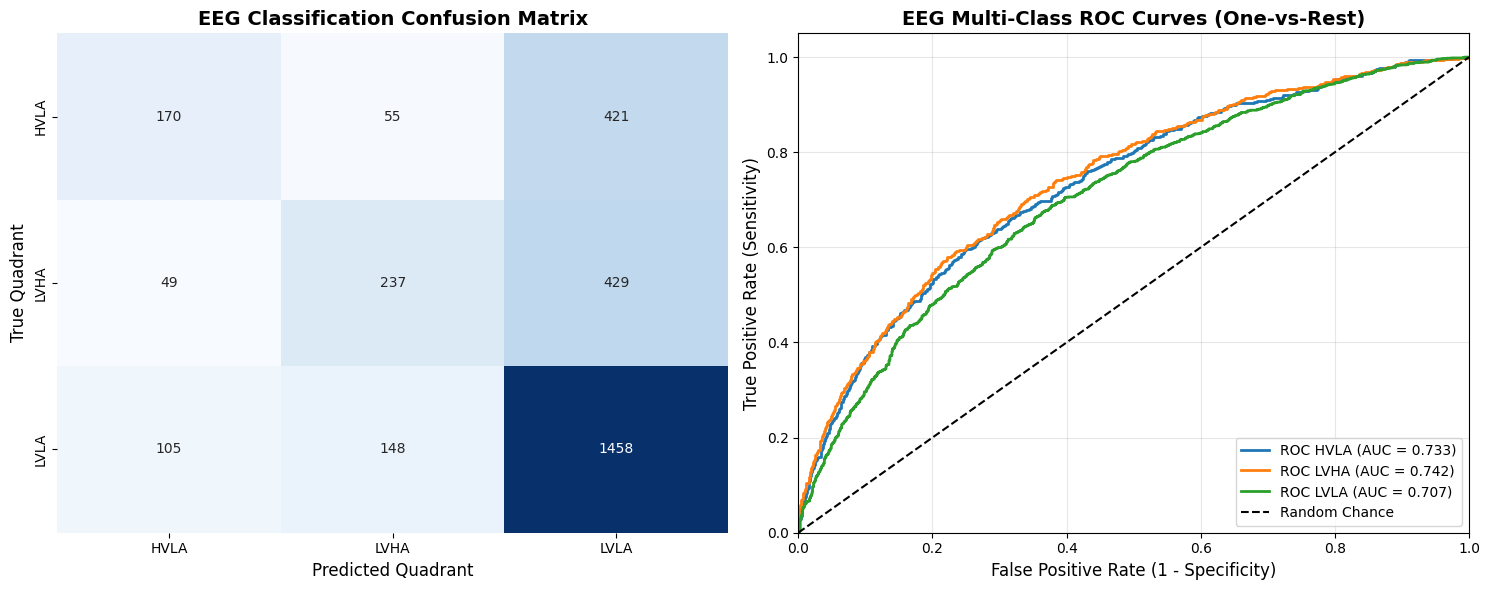


Evaluation metrics, prediction arrays, and plots saved successfully!


In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)


# 1. Generate Predictions from Trained XGBoost Model
y_pred = eeg_model.predict(X_test)
y_probs = eeg_model.predict_proba(X_test)

# 2. Compute Numerical Metrics
acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
auc_roc = roc_auc_score(y_test, y_probs, multi_class='ovr', average='macro')

# Print Metrics Summary
print("==========================================")
print("     EEG XGBOOST PERFORMANCE METRICS      ")
print("==========================================")
print(f"1. Accuracy         : {acc * 100:.2f}%")
print(f"2. Precision (Macro): {precision:.4f}")
print(f"3. Recall (Macro)   : {recall:.4f}")
print(f"4. F1-Score (Macro) : {f1:.4f}")
print(f"5. AUC-ROC (Macro)  : {auc_roc:.4f}")
print("==========================================\n")

# Detailed Per-Class Classification Report
print("Detailed Per-Class Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# 8. Plotting Setup (2 Subplots Side-by-Side)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# A. Visualizing Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
 cm, annot=True, fmt='d', cmap='Blues',
 xticklabels=target_names, yticklabels=target_names,
 ax=axes[0], cbar=False
)
axes[0].set_title('EEG Classification Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Quadrant', fontsize=12)
axes[0].set_ylabel('True Quadrant', fontsize=12)

# B. Visualizing One-vs-Rest Multi-Class AUC-ROC Curves
n_classes = len(target_names)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i in range(n_classes):
    y_true_binary = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_true_binary, y_probs[:, i])
    roc_auc_val = auc(fpr, tpr)

    axes[1].plot(
      fpr, tpr, color=colors[i % len(colors)], lw=2,
      label=f'ROC {target_names[i]} (AUC = {roc_auc_val:.3f})'
    )

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
axes[1].set_title('EEG Multi-Class ROC Curves (One-vs-Rest)', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Save Prediction Arrays and Plots for Late Fusion & Report
np.save(os.path.join(PROCESSED_PATH, 'eeg_test_probs.npy'), y_probs)
np.save(os.path.join(PROCESSED_PATH, 'eeg_test_labels.npy'), y_test)
joblib.dump(eeg_model, os.path.join(MODEL_PATH, 'eeg_xgboost.pkl'))

fig_path = os.path.join(PROCESSED_PATH, 'eeg_evaluation_plots.png')
fig.savefig(fig_path, dpi=300)

print(f"\nEvaluation metrics, prediction arrays, and plots saved successfully!")

In [41]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
)

In [46]:
# 1. Define Candidate Bagging Models
bagging_models = {
    "Random Forest (Standard Bagging)": RandomForestClassifier(
     n_estimators=300,
     max_depth=12,
     max_features='sqrt',
     n_jobs=-1,
     random_state=42
),
    "Extra Trees (Extremely Randomized Trees)": ExtraTreesClassifier(
     n_estimators=300,
     max_depth=14,
     max_features='sqrt',
     n_jobs=-1,
     random_state=42
),
"Bagging with RBF SVM Base": BaggingClassifier(
     estimator=SVC(probability=True, C=1.0, kernel='rbf'),
     n_estimators=30,
     max_samples=0.8,
     max_features=0.8,
     n_jobs=-1,
     random_state=42
)
}



In [43]:
best_acc = 0
best_model = None
best_model_name = ""
best_probs = None
best_preds = None

In [44]:
# 2. Iterate & Evaluate Bagging Algorithms
print("==========================================")
print("     EVALUATING BAGGING ALGORITHMS        ")
print("==========================================")

     EVALUATING BAGGING ALGORITHMS        



Training Random Forest (Standard Bagging)...
-> Accuracy         : 56.28%
-> Macro F1-Score   : 0.2655
-> Macro AUC-ROC    : 0.6917

Training Extra Trees (Extremely Randomized Trees)...
-> Accuracy         : 56.09%
-> Macro F1-Score   : 0.2580
-> Macro AUC-ROC    : 0.6799

Training Bagging with RBF SVM Base...
-> Accuracy         : 58.33%
-> Macro F1-Score   : 0.3627
-> Macro AUC-ROC    : 0.6830

 BEST BAGGING MODEL: Bagging with RBF SVM Base
 BEST ACCURACY     : 58.33%

Detailed Classification Report for Best Bagging Model:
              precision    recall  f1-score   support

        HVLA       0.59      0.09      0.15       646
        LVHA       0.60      0.13      0.21       715
        LVLA       0.58      0.96      0.73      1711

    accuracy                           0.58      3072
   macro avg       0.59      0.39      0.36      3072
weighted avg       0.59      0.58      0.48      3072



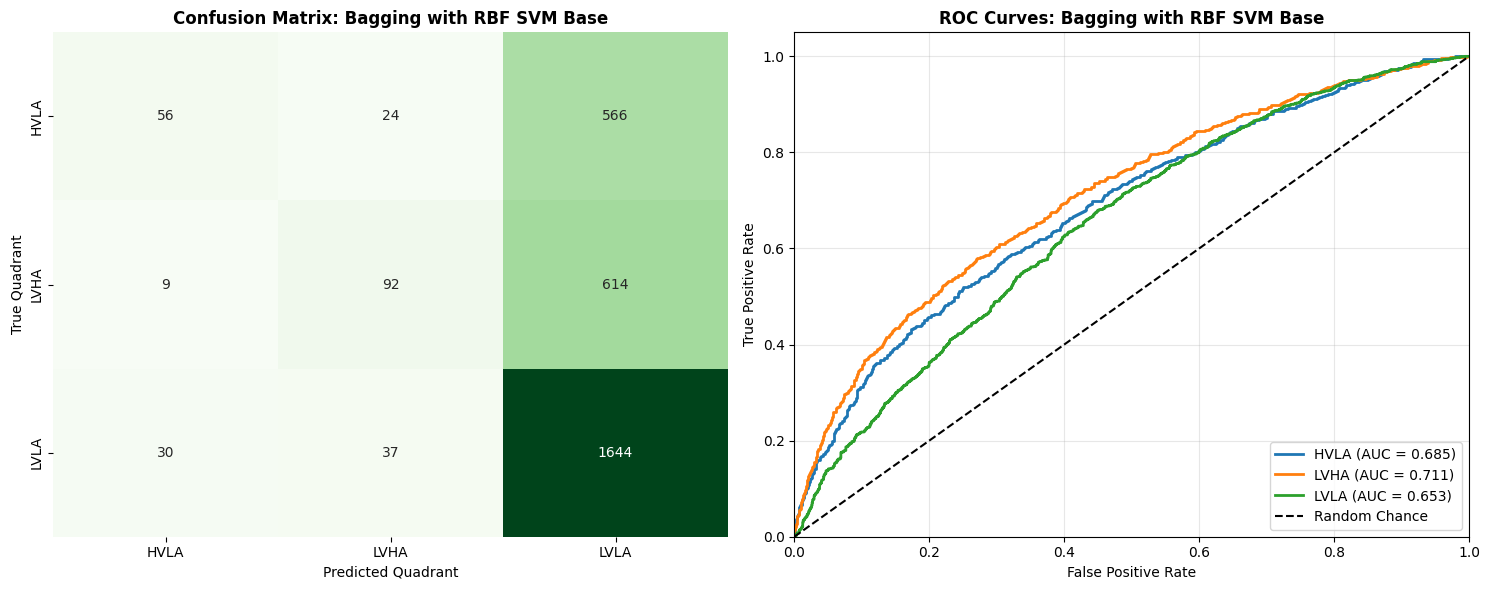

In [45]:
for name, model in bagging_models.items():
  print(f"\nTraining {name}...")
  model.fit(X_train, y_train)
  preds = model.predict(X_test)
  probs = model.predict_proba(X_test)
  acc = accuracy_score(y_test, preds)
  precision, recall, f1, _ = precision_recall_fscore_support(y_test, preds, average='macro')
  auc_roc = roc_auc_score(y_test, probs, multi_class='ovr', average='macro')
  print(f"-> Accuracy         : {acc * 100:.2f}%")
  print(f"-> Macro F1-Score   : {f1:.4f}")
  print(f"-> Macro AUC-ROC    : {auc_roc:.4f}")
  if acc > best_acc:
      best_acc = acc
      best_model = model
      best_model_name = name
      best_probs = probs
      best_preds = preds
print("\n==========================================")
print(f" BEST BAGGING MODEL: {best_model_name}")
print(f" BEST ACCURACY     : {best_acc * 100:.2f}%")
print("==========================================\n")
print("Detailed Classification Report for Best Bagging Model:")
print(classification_report(y_test, best_preds, target_names=target_names))

# 3. Plot Confusion Matrix & ROC Curve for the Winner
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
cm = confusion_matrix(y_test, best_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=target_names,
            yticklabels=target_names, ax=axes[0], cbar=False)
axes[0].set_title(f'Confusion Matrix: {best_model_name}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Quadrant')
axes[0].set_ylabel('True Quadrant')

n_classes = len(target_names)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i in range(n_classes):
      y_true_binary = (y_test == i).astype(int)
      fpr, tpr, _ = roc_curve(y_true_binary, best_probs[:, i])
      roc_auc_val = auc(fpr, tpr)
      axes[1].plot(fpr, tpr, color=colors[i % len(colors)],
                   lw=2, label=f'{target_names[i]} (AUC = {roc_auc_val:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curves: {best_model_name}', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Overwrite EEG Artifacts if Bagging beats XGBoost
if best_acc > acc: # Update saved probabilities for late fusion
    np.save(os.path.join(PROCESSED_PATH, 'eeg_test_probs.npy'), best_probs)
    np.save(os.path.join(PROCESSED_PATH, 'eeg_test_labels.npy'), y_test)
    joblib.dump(best_model, os.path.join(MODEL_PATH, 'eeg_best_bagging.pkl'))
    print("Saved updated EEG prediction probabilities to Drive for Late Fusion!")
